# Adaptive Evidential Fusion (ADEF)
## Multimodal Sentiment Analysis with Evidential Deep Learning (EDL)
**Author:** Erlangga Dewa Sakti  
**Specification:** *Adaptive Evidential Fusion for Uncertainty-Aware Cross-Modal Fusion in Multimodal Sentiment Analysis*

---
### 1. Setup & Environment Initialization

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from transformers import RobertaTokenizer, RobertaModel

from PIL import Image
import pandas as pd
import numpy as np
import os
import sys
import warnings
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILITY & SEEDING
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("[INFO] Imports loaded & global seed set to 42.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Imports loaded & global seed set to 42.
PyTorch version: 2.5.1
CUDA available: True
GPU Device: NVIDIA GeForce RTX 3060


---
### 2. Configuration (`CFG` Class)
Centralized configuration management for dataset parameters, backbone choices, ADEF hyperparameters, and training settings.

In [2]:
# ============================================================
# CONFIGURATION CLASS
# ============================================================

class CFG:
    # --- Seed & System Setup ---
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 0  # 0 for safe multi-processing on Windows

    # --- Dataset & File Paths ---
    DATASET_NAME = "MVSA-Single"
    # Auto-detect data path structure (Local workspace or D:/MVSA_SINGLE)
    ROOT_DIR = "D:/MVSA_SINGLE" if os.path.exists("D:/MVSA_SINGLE") else "./data/MVSA_Single"
    DATA_DIR = os.path.join(ROOT_DIR, "data") if os.path.exists(os.path.join(ROOT_DIR, "data")) else "./data/MVSA_Single/images"
    LABEL_PATH = os.path.join(ROOT_DIR, "labelResultAllFinal.txt") if os.path.exists(os.path.join(ROOT_DIR, "labelResultAllFinal.txt")) else "./data/MVSA_Single/data_label.csv"
    OUTPUT_DIR = "./output"

    # --- Unimodal Feature Backbones ---
    TEXT_BACKBONE = "roberta-base"        # HuggingFace Transformer
    IMAGE_BACKBONE = "densenet121"         # Torchvision Model
    FEATURE_DIM = 768                     # Dimensi proyeksi bersama (Embedding Alignment)
    NUM_CLASSES = 3                       # Sentimen: 0=Negative, 1=Neutral, 2=Positive

    # --- Image Preprocessing Settings ---
    IMAGE_SIZE = 224
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]

    # --- Text Preprocessing Settings ---
    MAX_LEN = 128

    # --- ADEF Threshold Hyperparameter ---
    TAU_THRESHOLD = 0.5                   # Ambang batas Conflict Mass (tau) dalam rentang [0.1, 0.9]

    # --- Training Hyperparameters ---
    BATCH_SIZE = 32
    EPOCHS = 20
    LR_BACKBONE = 2e-5                    # Fine-tuning rate untuk RoBERTa & DenseNet
    LR_HEAD = 1e-4                        # Learning rate untuk Co-Attention, ENN, dan ADEF Head
    WEIGHT_DECAY = 0.01
    KL_ANNEALING_EPOCHS = 10              # Epoch annealing untuk EDL KL Divergence Loss

    # --- Visualization & Logging ---
    SAVE_PLOTS = True
    PLOT_FORMAT = "png"                   # Format simpan grafik: 'png' atau 'pdf'

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
print(f"[INFO] CFG loaded. Operating on Device: {CFG.DEVICE}")
print(f"Dataset root: {CFG.ROOT_DIR}")
print(f"Output directory: {CFG.OUTPUT_DIR}")


[INFO] CFG loaded. Operating on Device: cuda
Dataset root: D:/MVSA_SINGLE
Output directory: ./output


---
### 3. Dataset & DataLoader
PyTorch `MultimodalDataset` handling paired image-text inputs, text tokenization with RoBERTa, image preprocessing, and stratified train/val/test splits.

In [3]:
# ============================================================
# DATA PREPARATION & PYTORCH DATASET
# ============================================================

def load_and_preprocess_dataframe():
    if CFG.LABEL_PATH.endswith(".txt"):
        df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
        df.columns = ["id", "text_label", "image_label", "final_label"]

        # Filter conflicting text/image sentiment pairs (e.g. positive text + negative image)
        def is_valid(row):
            if row["text_label"] == "positive" and row["image_label"] == "negative":
                return False
            if row["text_label"] == "negative" and row["image_label"] == "positive":
                return False
            return True

        df = df[df.apply(is_valid, axis=1)].reset_index(drop=True)
    else:
        df = pd.read_csv(CFG.LABEL_PATH)

    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    if "label" not in df.columns and "final_label" in df.columns:
        df["label"] = df["final_label"].map(label_map)

    # Load text content per ID if reading MVSA text files
    def load_text(sample_id):
        path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")
        if not os.path.exists(path):
            path_alt = os.path.join(CFG.ROOT_DIR, "data", f"{sample_id}.txt")
            if os.path.exists(path_alt):
                path = path_alt
            else:
                return ""
        encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]
        for enc in encodings:
            try:
                with open(path, "r", encoding=enc) as f:
                    text = f.read().strip()
                    if text:
                        return text
            except Exception:
                continue
        return ""

    if "text" not in df.columns or df["text"].isnull().all():
        df["text"] = df["id"].apply(load_text)

    # Build image paths
    def get_image_path(sample_id):
        img_path = os.path.join(CFG.DATA_DIR, f"{sample_id}.jpg")
        if not os.path.exists(img_path):
            img_path_alt = os.path.join(CFG.ROOT_DIR, "data", f"{sample_id}.jpg")
            if os.path.exists(img_path_alt):
                return img_path_alt
        return img_path

    df["image_path"] = df["id"].apply(get_image_path)
    return df

df_full = load_and_preprocess_dataframe()
print(f"Total samples after filtering: {len(df_full)}")

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, transform, max_len=128):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"]) if pd.notna(row["text"]) and str(row["text"]).strip() != "" else "empty"
        image_path = row["image_path"]
        label = int(row["label"])

        # Tokenize text with RoBERTa
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Load & transform image
        try:
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": torch.tensor(label, dtype=torch.long)
        }

# Preprocessing transforms & tokenizer
tokenizer = RobertaTokenizer.from_pretrained(CFG.TEXT_BACKBONE)
image_transform = transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CFG.NORM_MEAN, std=CFG.NORM_STD)
])

# Stratified 70% Train, 15% Val, 15% Test split
train_df, temp_df = train_test_split(df_full, test_size=0.30, stratify=df_full["label"], random_state=CFG.SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=CFG.SEED)

train_dataset = MultimodalDataset(train_df, tokenizer, image_transform, max_len=CFG.MAX_LEN)
val_dataset = MultimodalDataset(val_df, tokenizer, image_transform, max_len=CFG.MAX_LEN)
test_dataset = MultimodalDataset(test_df, tokenizer, image_transform, max_len=CFG.MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=CFG.NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"[INFO] DataLoaders Ready: Train ({len(train_df)}), Val ({len(val_df)}), Test ({len(test_df)})")


Total samples after filtering: 4511
[INFO] DataLoaders Ready: Train (3157), Val (677), Test (677)


---
### 4. Model Building Blocks
PyTorch implementations of `CoAttentionModule`, `EvidentialLayer` (ENN), and `ADEFModule` matching the exact mathematical formulas of the thesis proposal.

In [4]:
# ============================================================
# ARCHITECTURE BUILDING BLOCKS
# ============================================================

class CoAttentionModule(nn.Module):
    """
    Co-Attention Module:
    1. Correlation Matrix: A = Softmax(h_t * W * h_v^T) in R^(B x L x N)
    2. Cross-modal Attended Representations:
       h_c = Concat(Mean(h_t * A, dim=1), Mean(A^T * h_t, dim=1))
    """
    def __init__(self, feature_dim=768):
        super(CoAttentionModule, self).__init__()
        self.W = nn.Linear(feature_dim, feature_dim, bias=False)
        self.proj_c = nn.Linear(2 * feature_dim, feature_dim)
        self.layer_norm = nn.LayerNorm(feature_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, h_t, h_v):
        # h_t: (B, L, D), h_v: (B, N, D)
        # 1. Bidirectional Correlation Matrix A
        h_v_proj = self.W(h_v)                          # (B, N, D)
        scores = torch.matmul(h_t, h_v_proj.transpose(1, 2)) / (h_t.size(-1) ** 0.5) # (B, L, N)
        A = F.softmax(scores, dim=-1)                   # (B, L, N)

        # 2. Attended Features
        # Text-attended visual features: (B, L, N) x (B, N, D) -> (B, L, D)
        h_t_att = torch.matmul(A, h_v)
        # Visual-attended text features: (B, N, L) x (B, L, D) -> (B, N, D)
        h_v_att = torch.matmul(A.transpose(1, 2), h_t)

        # Pooling across sequence/spatial dimensions
        bar_h_t = h_t_att.mean(dim=1)                   # (B, D)
        bar_h_v = h_v_att.mean(dim=1)                   # (B, D)

        # Cross-modal fusion representation h_c
        h_c_cat = torch.cat([bar_h_t, bar_h_v], dim=-1) # (B, 2D)
        h_c = self.dropout(F.relu(self.proj_c(h_c_cat)))
        h_c = self.layer_norm(h_c)                      # (B, D)
        return h_c, A


class EvidentialLayer(nn.Module):
    """
    Evidential Neural Network (ENN) Layer:
    - Evidence: e_k,i = ReLU(W_k * h_k + b_k) >= 0
    - Dirichlet Parameters: alpha_k,i = e_k,i + 1
    - Dirichlet Strength: S_k = sum(alpha_k,i)
    - Belief Mass: b_k,i = e_k,i / S_k
    - Uncertainty Mass: u_k = M / S_k
    """
    def __init__(self, in_dim=768, num_classes=3):
        super(EvidentialLayer, self).__init__()
        self.fc = nn.Linear(in_dim, num_classes)
        self.num_classes = num_classes

    def forward(self, h):
        logits = self.fc(h)
        evidence = F.relu(logits)                        # e_k,i >= 0
        alpha = evidence + 1.0                           # alpha_k,i = e_k,i + 1
        S = torch.sum(alpha, dim=-1, keepdim=True)       # S_k = sum(alpha_k,i)
        b = evidence / S                                 # b_k,i = e_k,i / S_k
        u = self.num_classes / S                         # u_k = M / S_k
        return {
            "evidence": evidence,
            "alpha": alpha,
            "b": b,
            "u": u,
            "S": S
        }


class ADEFModule(nn.Module):
    """
    Adaptive Evidential Fusion (ADEF) Module:
    1. Conflict Mass K_tv = sum_{i != j} b_t,i * b_v,j
    2. Dynamic Branching:
       - Route A (K_tv <= tau): Standard Dempster-Shafer Combination (T (+) V) (+) C
       - Route B (K_tv > tau): Conflict-Aware Fusion:
         b_fusion = (1 - K_tv) * (b_t + b_v)/2 + K_tv * b_c
         u_fusion = 1 - sum(b_fusion)
    3. Final Prediction Probability: p_i = b_fusion,i + u_fusion / M
    """
    def __init__(self, tau=0.5, num_classes=3):
        super(ADEFModule, self).__init__()
        self.tau = tau
        self.num_classes = num_classes

    def forward(self, b_t, u_t, b_v, u_v, b_c, u_c):
        # b_t, b_v, b_c: (B, M), u_t, u_v, u_c: (B, 1)

        # 1. Conflict Mass K_tv calculation: K_tv = sum_{i != j} b_t,i * b_v,j
        b_t_sum = b_t.sum(dim=-1, keepdim=True)         # (B, 1)
        b_v_sum = b_v.sum(dim=-1, keepdim=True)         # (B, 1)
        K_tv = b_t_sum * b_v_sum - torch.sum(b_t * b_v, dim=-1, keepdim=True) # (B, 1)
        K_tv = torch.clamp(K_tv, min=0.0, max=0.9999)

        # ------------------------------------------------------------
        # ROUTE A: Standard Dempster-Shafer Combination (K_tv <= tau)
        # ------------------------------------------------------------
        denom_tv = torch.clamp(1.0 - K_tv, min=1e-8)
        b_tv = (b_t * b_v + b_t * u_v + b_v * u_t) / denom_tv  # (B, M)
        u_tv = (u_t * u_v) / denom_tv                          # (B, 1)

        # Hybrid DS Fusion with Co-Attention (TV (+) C)
        b_tv_sum = b_tv.sum(dim=-1, keepdim=True)
        b_c_sum = b_c.sum(dim=-1, keepdim=True)
        K_tvc = b_tv_sum * b_c_sum - torch.sum(b_tv * b_c, dim=-1, keepdim=True)
        denom_tvc = torch.clamp(1.0 - K_tvc, min=1e-8)

        b_routeA = (b_tv * b_c + b_tv * u_c + b_c * u_tv) / denom_tvc # (B, M)
        u_routeA = (u_tv * u_c) / denom_tvc                           # (B, 1)

        # ------------------------------------------------------------
        # ROUTE B: Adaptive Conflict-Aware Fusion (K_tv > tau)
        # ------------------------------------------------------------
        b_routeB = (1.0 - K_tv) * ((b_t + b_v) / 2.0) + K_tv * b_c   # (B, M)
        u_routeB = 1.0 - torch.sum(b_routeB, dim=-1, keepdim=True)   # (B, 1)
        u_routeB = torch.clamp(u_routeB, min=0.0)

        # ------------------------------------------------------------
        # DYNAMIC SELECTION (VECTORIZED BATCH BRANCHING)
        # ------------------------------------------------------------
        route_a_mask = (K_tv <= self.tau)                             # (B, 1)
        b_fusion = torch.where(route_a_mask, b_routeA, b_routeB)     # (B, M)
        u_fusion = torch.where(route_a_mask, u_routeA, u_routeB)     # (B, 1)

        # 3. Final Probability Vector: p_i = b_fusion,i + u_fusion / M
        p = b_fusion + (u_fusion / self.num_classes)                  # (B, M)

        return p, b_fusion, u_fusion, K_tv

print("[INFO] Architecture Building Blocks (`CoAttentionModule`, `EvidentialLayer`, `ADEFModule`) successfully defined.")


[INFO] Architecture Building Blocks (`CoAttentionModule`, `EvidentialLayer`, `ADEFModule`) successfully defined.


---
### 5. Full Model Assembly (`ADEFModel`)
Complete end-to-end architecture fusing RoBERTa text features, DenseNet121 visual features, Co-Attention, and Adaptive Evidential Fusion.

In [5]:
# ============================================================
# FULL ADEF MODEL ASSEMBLY
# ============================================================

class ADEFModel(nn.Module):
    def __init__(self, cfg):
        super(ADEFModel, self).__init__()
        self.cfg = cfg

        # 1. Text Encoder (RoBERTa)
        self.text_encoder = RobertaModel.from_pretrained(cfg.TEXT_BACKBONE)
        self.text_proj = nn.Linear(self.text_encoder.config.hidden_size, cfg.FEATURE_DIM)

        # 2. Visual Encoder (DenseNet121)
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.visual_encoder = densenet.features
        # DenseNet121 features output 1024 channels
        self.visual_proj = nn.Linear(1024, cfg.FEATURE_DIM)

        # 3. Co-Attention Module
        self.co_attention = CoAttentionModule(feature_dim=cfg.FEATURE_DIM)

        # 4. Evidential Neural Networks (ENN)
        self.enn_text = EvidentialLayer(in_dim=cfg.FEATURE_DIM, num_classes=cfg.NUM_CLASSES)
        self.enn_visual = EvidentialLayer(in_dim=cfg.FEATURE_DIM, num_classes=cfg.NUM_CLASSES)
        self.enn_coatt = EvidentialLayer(in_dim=cfg.FEATURE_DIM, num_classes=cfg.NUM_CLASSES)

        # 5. Adaptive Evidential Fusion Module
        self.adef = ADEFModule(tau=cfg.TAU_THRESHOLD, num_classes=cfg.NUM_CLASSES)

    def forward(self, input_ids, attention_mask, image):
        # A. Unimodal Text Feature Extraction
        text_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        h_t_seq = self.text_proj(text_out.last_hidden_state)     # (B, L, D)
        h_t = h_t_seq.mean(dim=1)                               # (B, D)

        # B. Unimodal Visual Feature Extraction
        v_feat = self.visual_encoder(image)                     # (B, 1024, 7, 7)
        B, C, H, W = v_feat.size()
        v_spatial = v_feat.view(B, C, H * W).permute(0, 2, 1)    # (B, N=49, 1024)
        h_v_spatial = self.visual_proj(v_spatial)               # (B, N, D)
        h_v = h_v_spatial.mean(dim=1)                           # (B, D)

        # C. Co-Attention Module
        h_c, attn_matrix = self.co_attention(h_t_seq, h_v_spatial) # (B, D), (B, L, N)

        # D. ENN Evidence Calculation for Text, Visual, & Co-Attention
        enn_t = self.enn_text(h_t)
        enn_v = self.enn_visual(h_v)
        enn_c = self.enn_coatt(h_c)

        # E. Adaptive Evidential Fusion (ADEF)
        p, b_fusion, u_fusion, K_tv = self.adef(
            enn_t["b"], enn_t["u"],
            enn_v["b"], enn_v["u"],
            enn_c["b"], enn_c["u"]
        )

        return {
            "probs": p,
            "b_fusion": b_fusion,
            "u_fusion": u_fusion,
            "K_tv": K_tv,
            "enn_text": enn_t,
            "enn_visual": enn_v,
            "enn_coatt": enn_c,
            "attn_matrix": attn_matrix
        }

model = ADEFModel(CFG).to(CFG.DEVICE)
print(f"[INFO] `ADEFModel` assembled successfully on device {CFG.DEVICE}.")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3830.04it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[INFO] `ADEFModel` assembled successfully on device cuda.


---
### 6. Evidential Loss Function & Optimizer Setup
Implementation of `EDLLoss` combining expected MSE loss under Dirichlet distribution and KL Divergence regularization with epoch annealing.

In [6]:
# ============================================================
# EVIDENTIAL DEEP LEARNING (EDL) LOSS & OPTIMIZER
# ============================================================

class EDLLoss(nn.Module):
    """
    Evidential Deep Learning (EDL) Loss:
    L_EDL = L_MSE + lambda_t * L_KL
    Where L_MSE = sum_i (y_i - alpha_i / S)^2 + (alpha_i / S * (1 - alpha_i / S)) / (S + 1)
    and L_KL is Dirichlet KL-divergence to uniform distribution.
    """
    def __init__(self, num_classes=3):
        super(EDLLoss, self).__init__()
        self.num_classes = num_classes

    def kl_divergence(self, alpha, num_classes):
        beta = torch.ones((1, num_classes), dtype=torch.float32, device=alpha.device)
        S_alpha = torch.sum(alpha, dim=-1, keepdim=True)
        S_beta = torch.sum(beta, dim=-1, keepdim=True)

        lnB = torch.lgamma(S_alpha) - torch.sum(torch.lgamma(alpha), dim=-1, keepdim=True)
        lnB_prior = torch.sum(torch.lgamma(beta), dim=-1, keepdim=True) - torch.lgamma(S_beta)

        dgAlpha = torch.digamma(alpha)
        dgSAlpha = torch.digamma(S_alpha)

        kl = torch.sum((alpha - beta) * (dgAlpha - dgSAlpha), dim=-1, keepdim=True) + lnB + lnB_prior
        return kl

    def forward(self, alpha, y_onehot, epoch, annealing_epochs):
        # alpha: (B, M), y_onehot: (B, M)
        S = torch.sum(alpha, dim=-1, keepdim=True)
        p_hat = alpha / S

        # 1. MSE Loss under Dirichlet Expectation & Variance
        err = y_onehot - p_hat
        var = (p_hat * (1.0 - p_hat)) / (S + 1.0)
        l_mse = torch.sum(err ** 2 + var, dim=-1, keepdim=True)

        # 2. KL Regularization Loss (removes evidence of non-groundtruth classes)
        alpha_tilde = y_onehot + (1.0 - y_onehot) * alpha
        kl_reg = self.kl_divergence(alpha_tilde, self.num_classes)

        # 3. Annealing coefficient
        annealing_coef = min(1.0, float(epoch) / float(annealing_epochs))
        total_loss = l_mse + annealing_coef * kl_reg

        return torch.mean(total_loss)

edl_criterion = EDLLoss(num_classes=CFG.NUM_CLASSES)

# Differential Learning Rates Setup (Backbones vs Heads)
backbone_params = list(model.text_encoder.parameters()) + list(model.visual_encoder.parameters())
head_params = (
    list(model.text_proj.parameters()) +
    list(model.visual_proj.parameters()) +
    list(model.co_attention.parameters()) +
    list(model.enn_text.parameters()) +
    list(model.enn_visual.parameters()) +
    list(model.enn_coatt.parameters()) +
    list(model.adef.parameters())
)

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": CFG.LR_BACKBONE},
    {"params": head_params, "lr": CFG.LR_HEAD}
], weight_decay=CFG.WEIGHT_DECAY)

print("[INFO] `EDLLoss` and AdamW Optimizer (with differential learning rates) initialized.")


[INFO] `EDLLoss` and AdamW Optimizer (with differential learning rates) initialized.


---
### 7. Training & Validation Loop
Full training pipeline tracking loss curves, KL annealing, validation Macro F1 score, and saving the best checkpoint.

In [7]:
# ============================================================
# TRAINING & VALIDATION PIPELINE
# ============================================================

def train_epoch(model, dataloader, criterion, optimizer, epoch, cfg):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{cfg.EPOCHS} [Train]")
    for batch in pbar:
        input_ids = batch["input_ids"].to(cfg.DEVICE)
        attention_mask = batch["attention_mask"].to(cfg.DEVICE)
        images = batch["image"].to(cfg.DEVICE)
        labels = batch["label"].to(cfg.DEVICE)

        optimizer.zero_grad()
        out = model(input_ids, attention_mask, images)

        # Calculate loss on ADEF fused alpha parameters & unimodal alphas
        y_onehot = F.one_hot(labels, num_classes=cfg.NUM_CLASSES).float()

        # Combined EDL loss across fused branch and unimodal heads
        alpha_fused = out["b_fusion"] * (cfg.NUM_CLASSES / torch.clamp(out["u_fusion"], min=1e-6)) + 1.0
        loss_fused = criterion(alpha_fused, y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)
        loss_t = criterion(out["enn_text"]["alpha"], y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)
        loss_v = criterion(out["enn_visual"]["alpha"], y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)
        loss_c = criterion(out["enn_coatt"]["alpha"], y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)

        loss = loss_fused + 0.2 * (loss_t + loss_v + loss_c)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(out["probs"], dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_loss = total_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


def evaluate(model, dataloader, criterion, epoch, cfg):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(cfg.DEVICE)
            attention_mask = batch["attention_mask"].to(cfg.DEVICE)
            images = batch["image"].to(cfg.DEVICE)
            labels = batch["label"].to(cfg.DEVICE)

            out = model(input_ids, attention_mask, images)
            y_onehot = F.one_hot(labels, num_classes=cfg.NUM_CLASSES).float()

            alpha_fused = out["b_fusion"] * (cfg.NUM_CLASSES / torch.clamp(out["u_fusion"], min=1e-6)) + 1.0
            loss = criterion(alpha_fused, y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)

            total_loss += loss.item()
            preds = torch.argmax(out["probs"], dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    val_loss = total_loss / len(dataloader)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average="macro")
    return val_loss, val_acc, val_f1

# Execute Training Loop
history = {
    "train_loss": [], "train_acc": [], "train_f1": [],
    "val_loss": [], "val_acc": [], "val_f1": []
}

best_val_f1 = 0.0
best_model_path = os.path.join(CFG.OUTPUT_DIR, "best_adef_model.pt")

for epoch in range(CFG.EPOCHS):
    tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, edl_criterion, optimizer, epoch, CFG)
    vl_loss, vl_acc, vl_f1 = evaluate(model, val_loader, edl_criterion, epoch, CFG)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["train_f1"].append(tr_f1)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    print(f"Epoch {epoch+1:02d}/{CFG.EPOCHS:02d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} F1: {tr_f1:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} F1: {vl_f1:.4f}")

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> Best Model Saved! Val Macro F1: {best_val_f1:.4f}")

print("[INFO] Training complete.")


Epoch 1/20 [Train]: 100%|██████████| 99/99 [02:23<00:00,  1.45s/it, loss=0.7096]


Epoch 01/20 | Train Loss: 0.8691 Acc: 0.6402 F1: 0.4094 | Val Loss: 0.4515 Acc: 0.6898 F1: 0.4713
  --> Best Model Saved! Val Macro F1: 0.4713


Epoch 2/20 [Train]: 100%|██████████| 99/99 [01:29<00:00,  1.11it/s, loss=0.7761]


Epoch 02/20 | Train Loss: 0.7580 Acc: 0.7583 F1: 0.5534 | Val Loss: 0.5311 Acc: 0.7282 F1: 0.5495
  --> Best Model Saved! Val Macro F1: 0.5495


Epoch 3/20 [Train]: 100%|██████████| 99/99 [01:34<00:00,  1.05it/s, loss=0.6475]


...

Epoch 18/20 | Train Loss: 0.1346 Acc: 0.9886 F1: 0.9842 | Val Loss: 2.1482 Acc: 0.7312 F1: 0.6072


Epoch 19/20 [Train]: 100%|██████████| 99/99 [01:25<00:00,  1.16it/s, loss=0.7237]


Epoch 19/20 | Train Loss: 0.1380 Acc: 0.9892 F1: 0.9845 | Val Loss: 2.3223 Acc: 0.7061 F1: 0.5798


Epoch 20/20 [Train]: 100%|██████████| 99/99 [01:25<00:00,  1.16it/s, loss=0.0525]


Epoch 20/20 | Train Loss: 0.1205 Acc: 0.9889 F1: 0.9841 | Val Loss: 2.2234 Acc: 0.7208 F1: 0.6071
[INFO] Training complete.


---
### 8. Evaluation & Test Pipeline
Testing model on unseen data, gathering predictions, ground truths, belief masses, uncertainty masses, and conflict masses ($K_{tv}$).

In [8]:
# ============================================================
# EVALUATION & TEST SET EXECUTION
# ============================================================

if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=CFG.DEVICE))
    print(f"[INFO] Best model weights loaded from {best_model_path}")

model.eval()

test_preds = []
test_labels = []
test_probs = []
test_u_fusion = []
test_K_tv = []
test_b_fusion = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing Model"):
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        out = model(input_ids, attention_mask, images)
        preds = torch.argmax(out["probs"], dim=-1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(out["probs"].cpu().numpy())
        test_u_fusion.extend(out["u_fusion"].squeeze(-1).cpu().numpy())
        test_K_tv.extend(out["K_tv"].squeeze(-1).cpu().numpy())
        test_b_fusion.extend(out["b_fusion"].cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)
test_u_fusion = np.array(test_u_fusion)
test_K_tv = np.array(test_K_tv)
test_b_fusion = np.array(test_b_fusion)

test_acc = accuracy_score(test_labels, test_preds)
test_f1_macro = f1_score(test_labels, test_preds, average="macro")
test_precision_macro = precision_score(test_labels, test_preds, average="macro")
test_recall_macro = recall_score(test_labels, test_preds, average="macro")

print("="*60)
print("FINAL TEST PERFORMANCE SUMMARY:")
print("="*60)
print(f"Test Accuracy:          {test_acc * 100:.2f}%")
print(f"Test Macro Precision:   {test_precision_macro * 100:.2f}%")
print(f"Test Macro Recall:      {test_recall_macro * 100:.2f}%")
print(f"Test Macro F1-Score:    {test_f1_macro * 100:.2f}%")
print("="*60)

target_names = ["Negative", "Neutral", "Positive"]
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))


[INFO] Best model weights loaded from ./output\best_adef_model.pt


Testing Model: 100%|██████████| 22/22 [00:24<00:00,  1.09s/it]

FINAL TEST PERFORMANCE SUMMARY:
Test Accuracy:          75.04%
Test Macro Precision:   66.98%
Test Macro Recall:      62.06%
Test Macro F1-Score:    63.57%
              precision    recall  f1-score   support

    Negative     0.6986    0.7157    0.7070       204
     Neutral     0.5122    0.3000    0.3784        70
    Positive     0.7986    0.8462    0.8217       403

    accuracy                         0.7504       677
   macro avg     0.6698    0.6206    0.6357       677
weighted avg     0.7388    0.7504    0.7413       677



---
### 9. Comprehensive Plotting & Visualizations (300 DPI)
Publication-grade visualizations of evaluation metrics, uncertainty distributions, conflict mass routing, and performance dynamics.

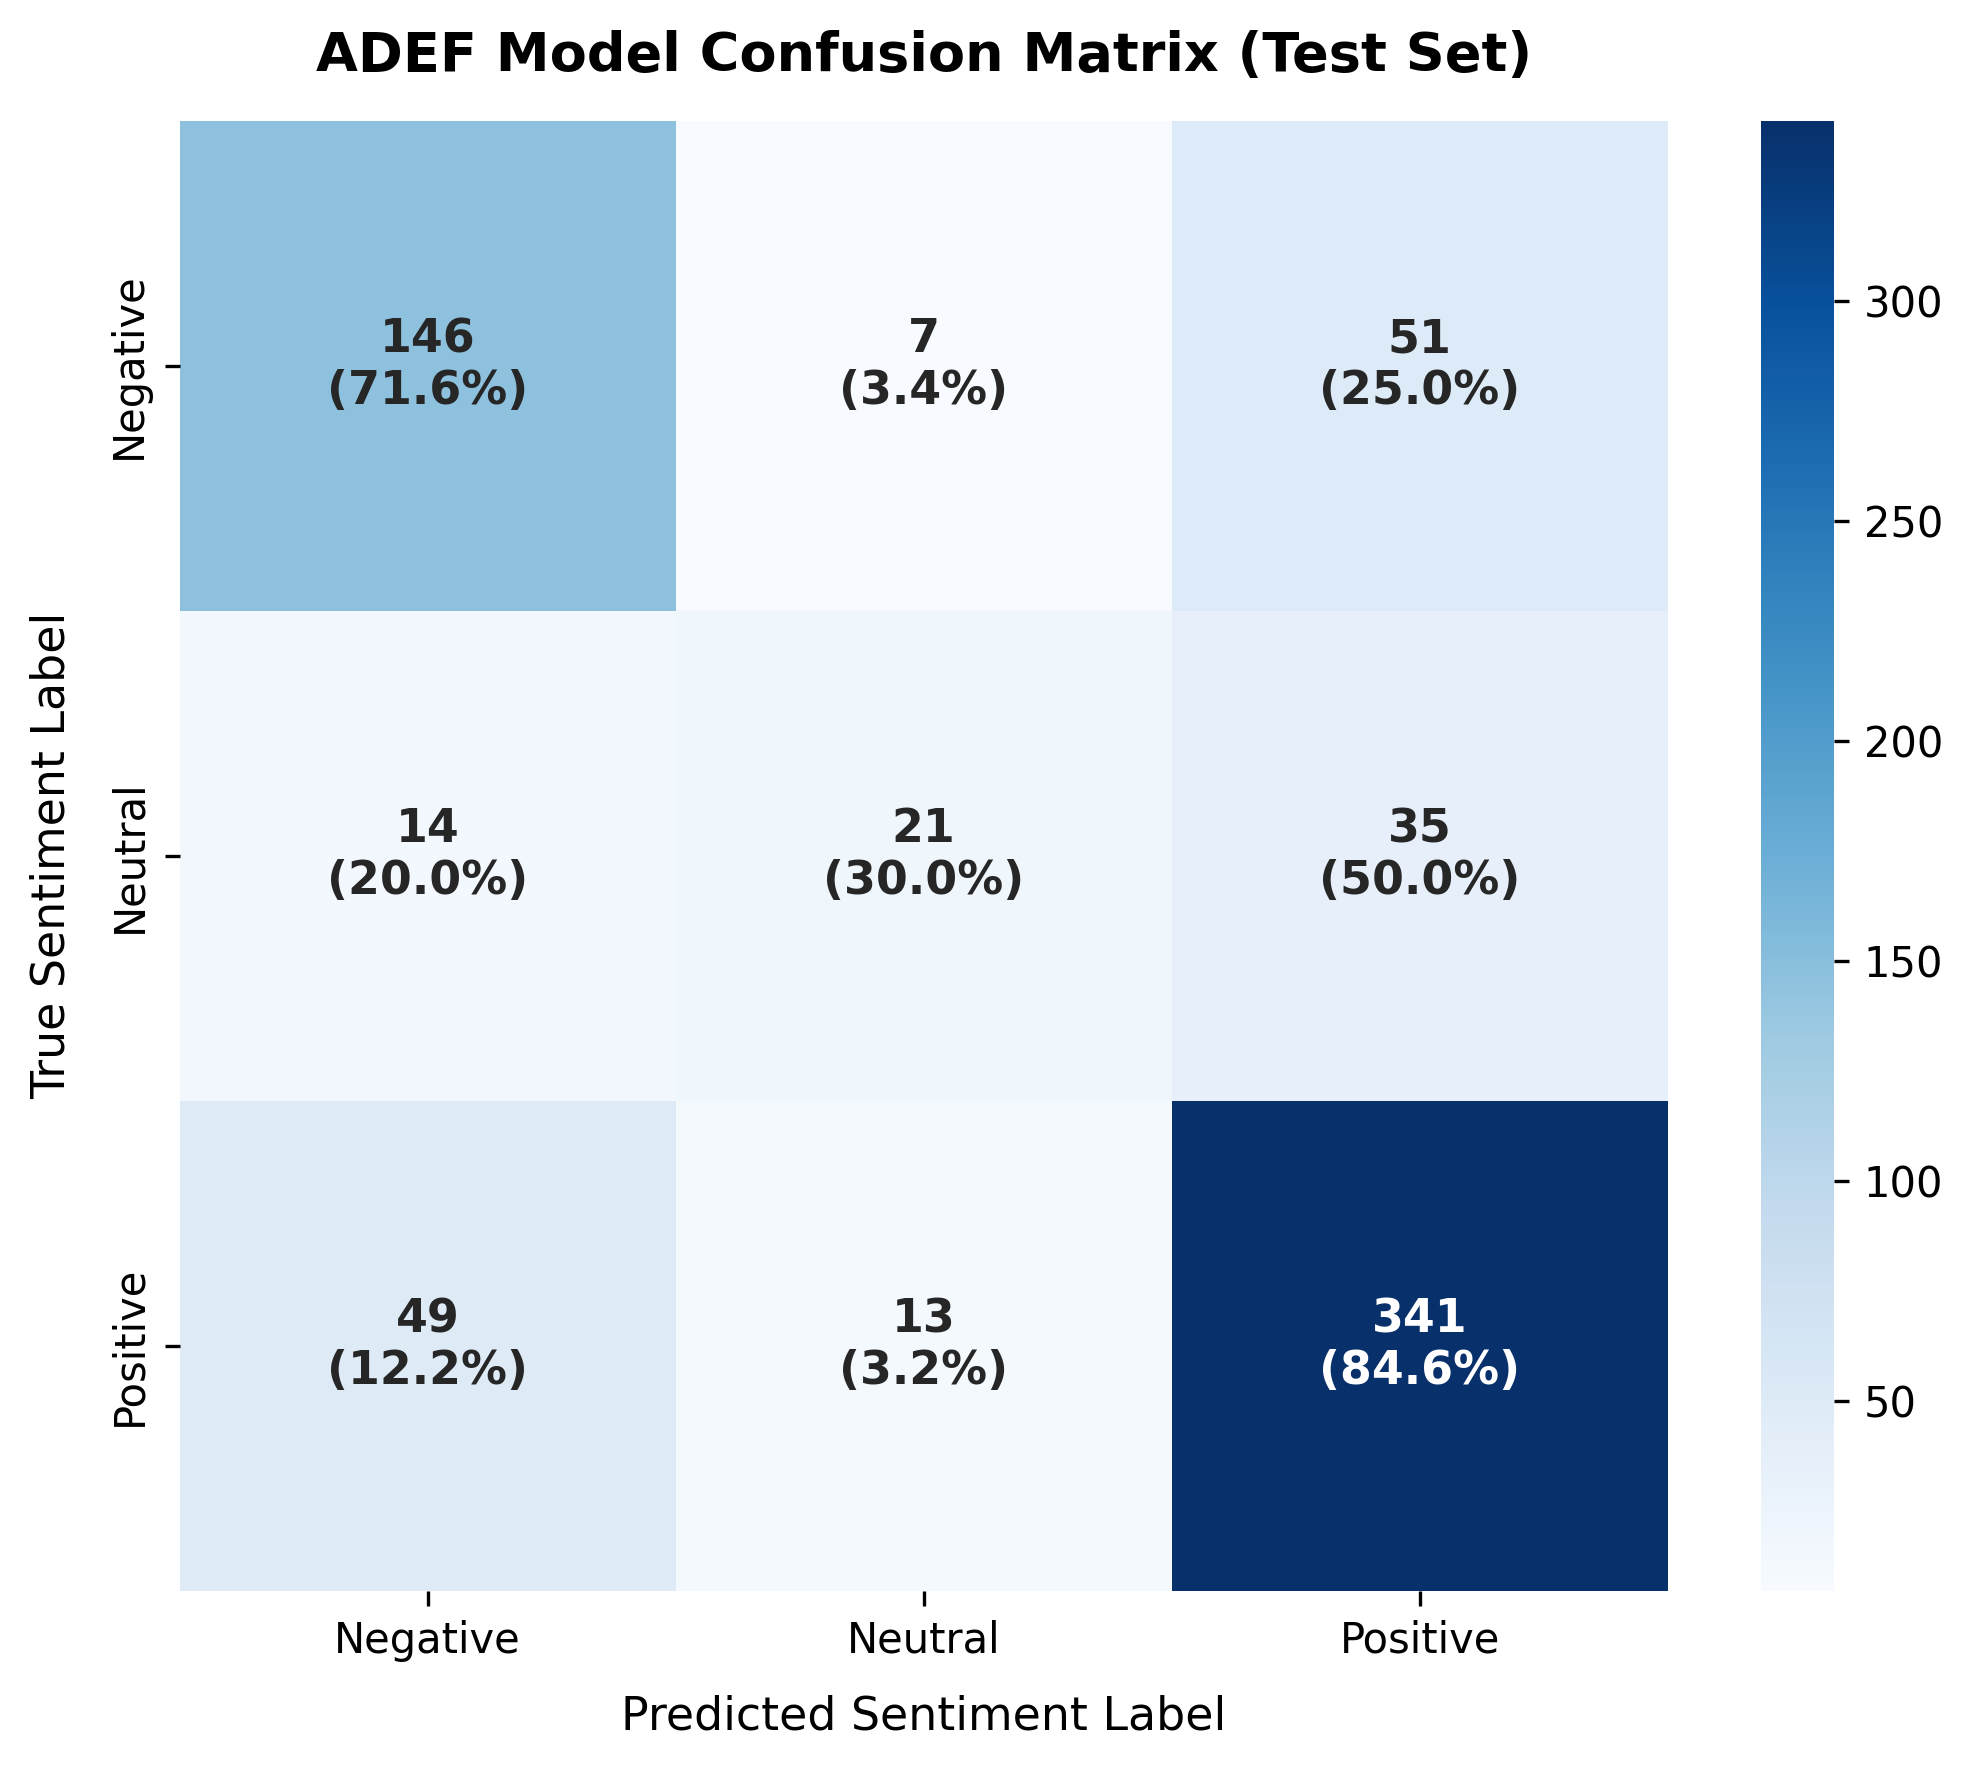

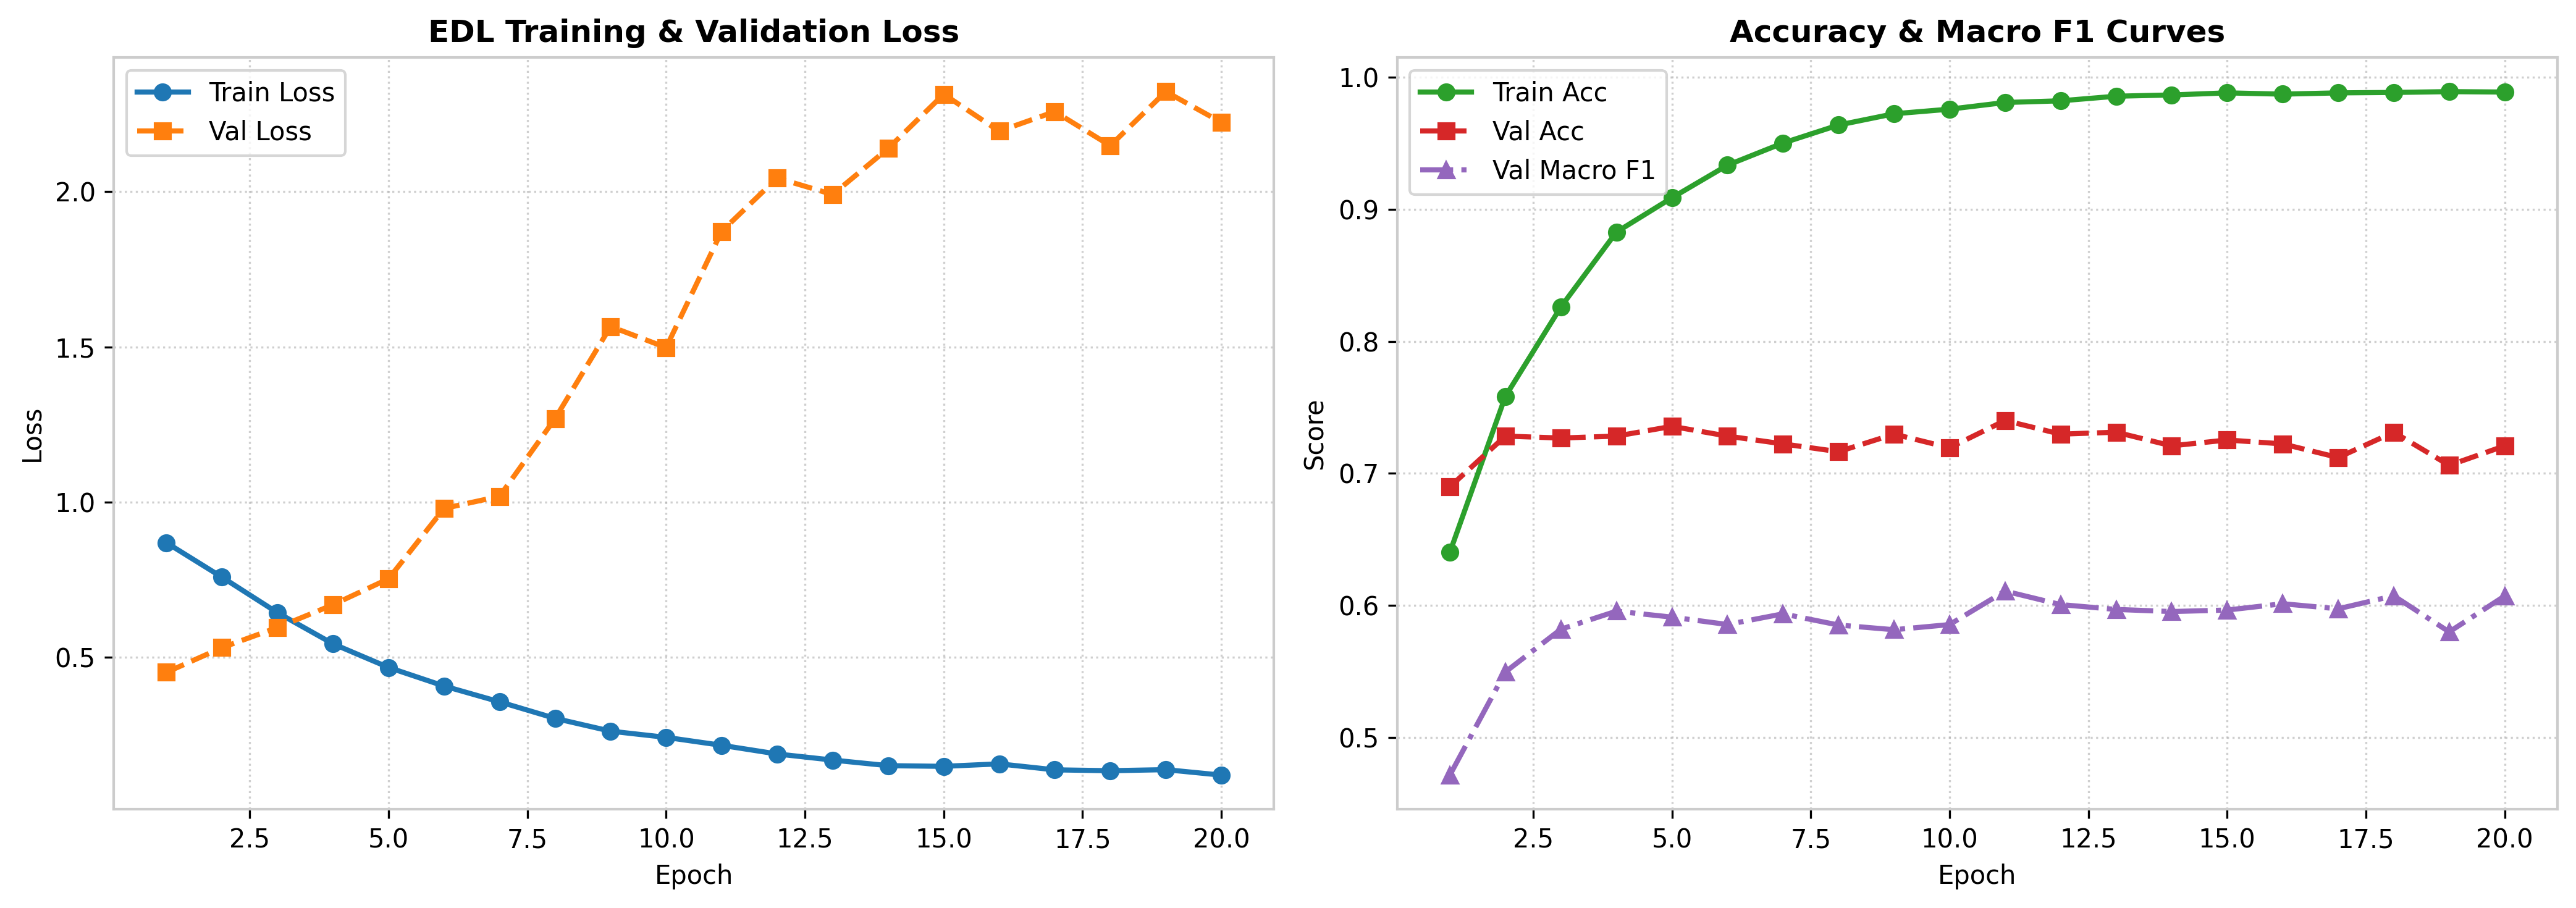

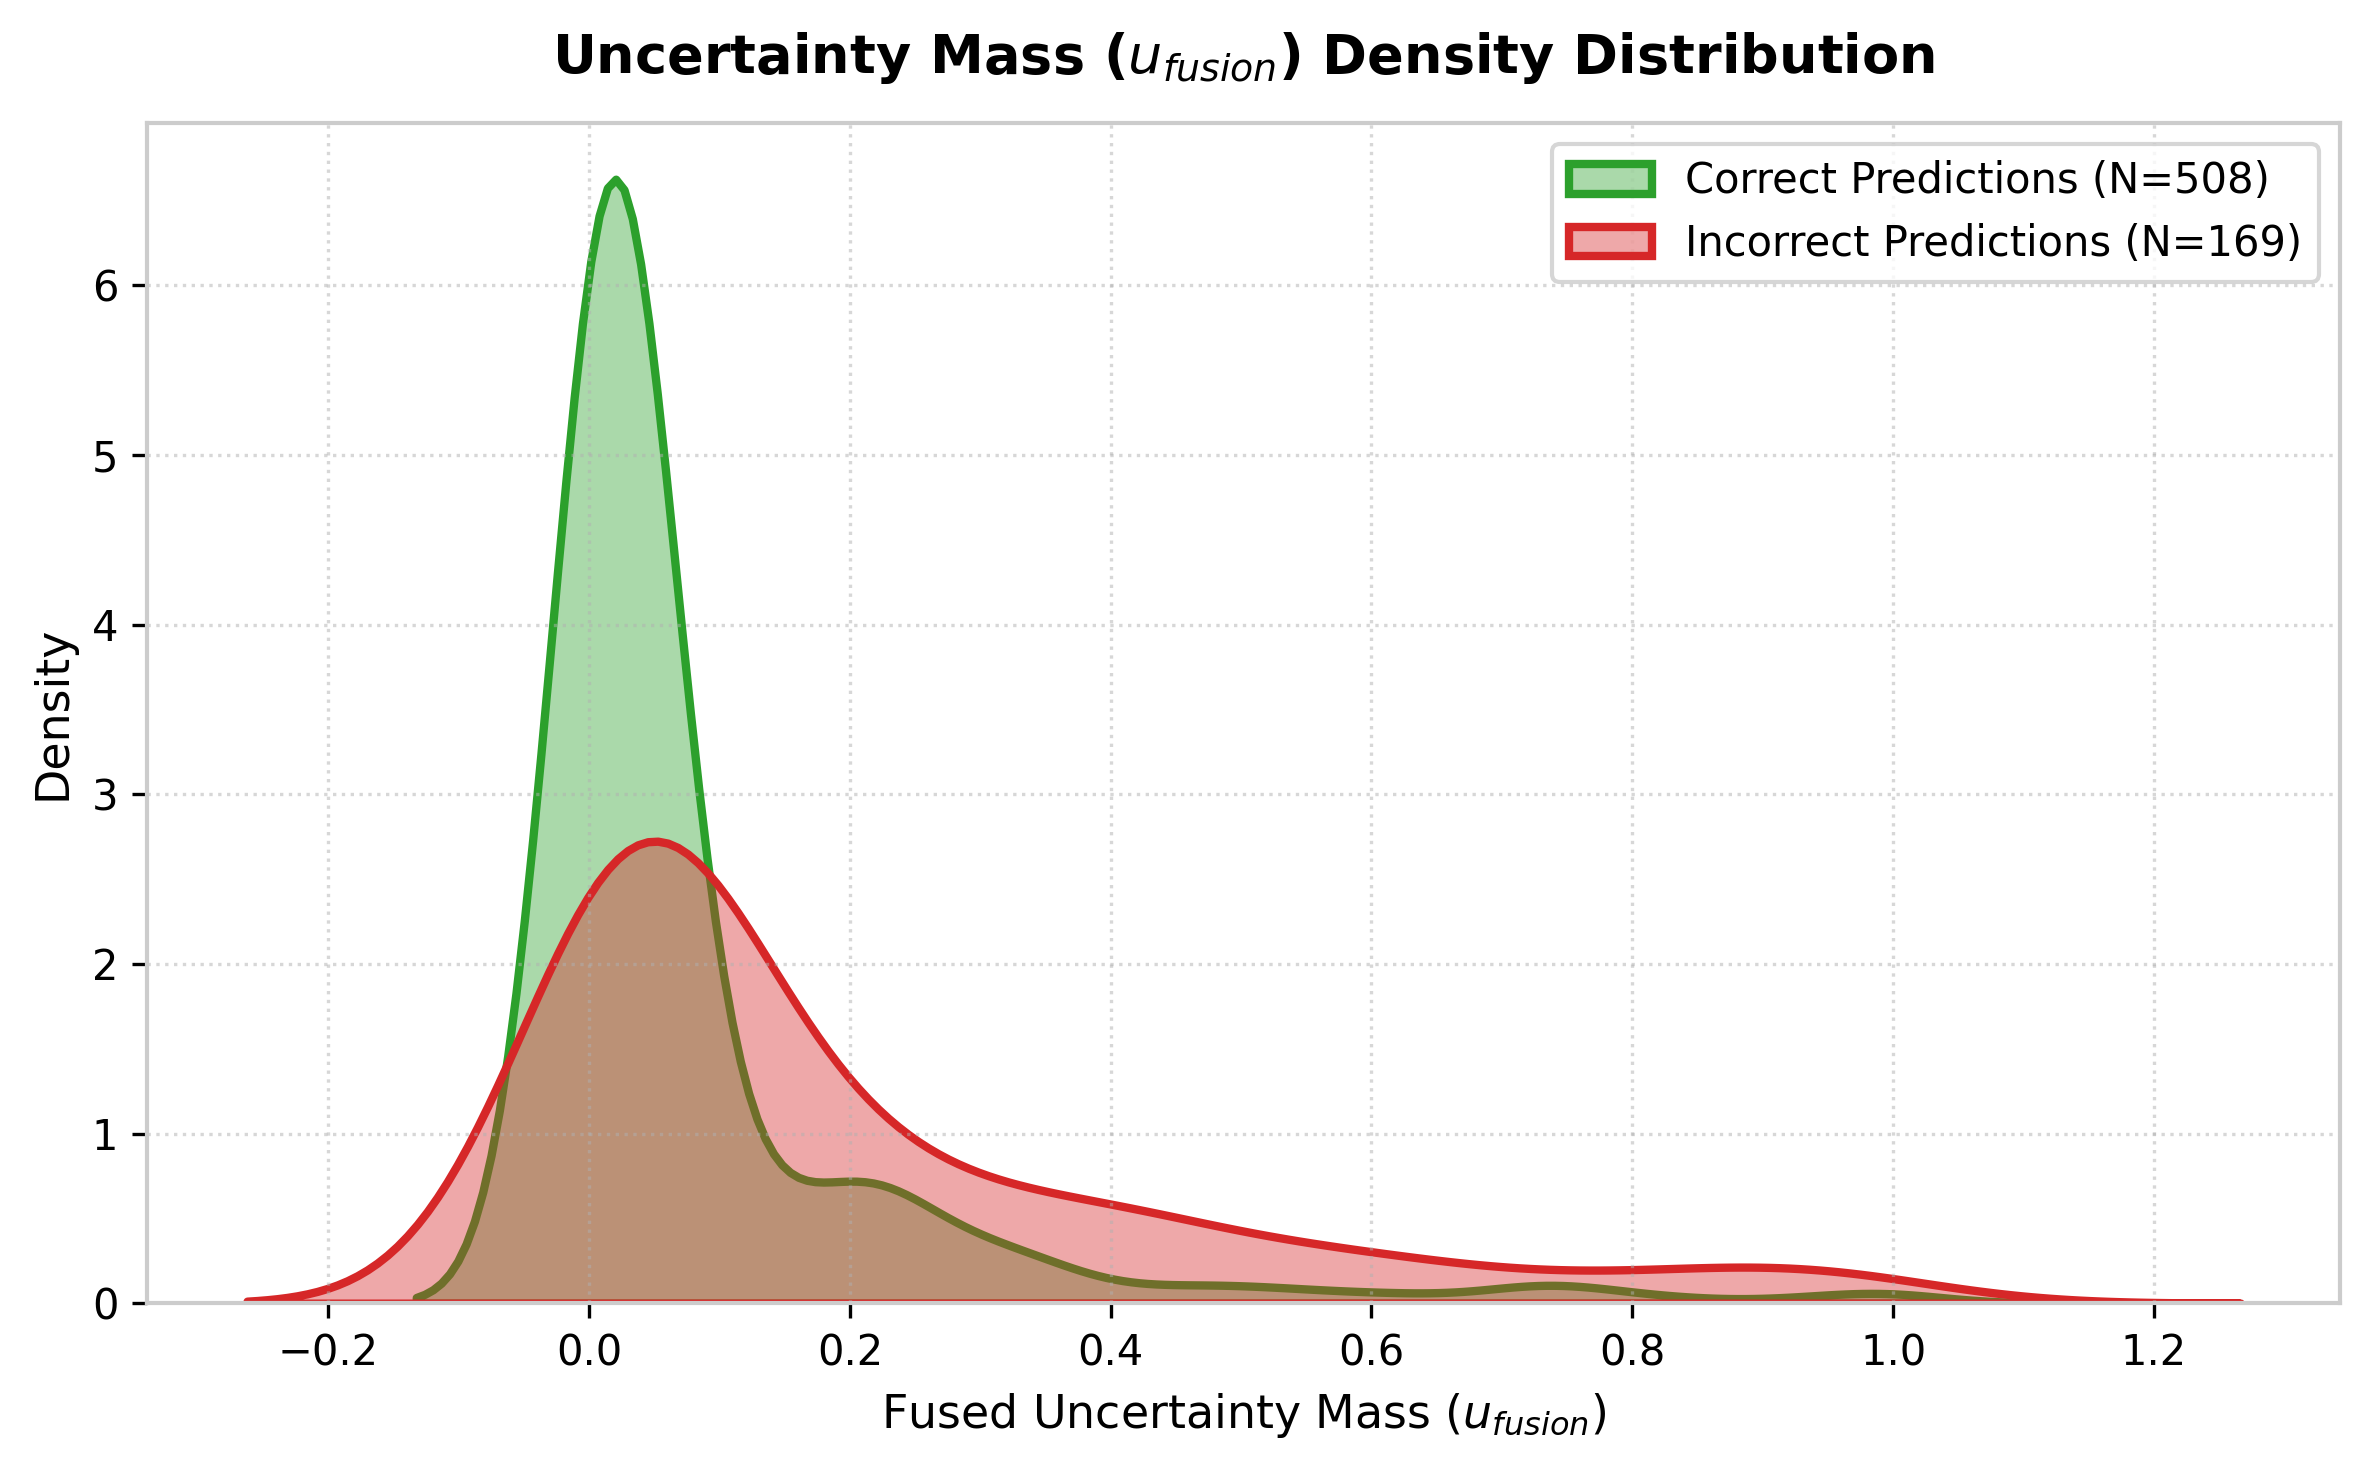

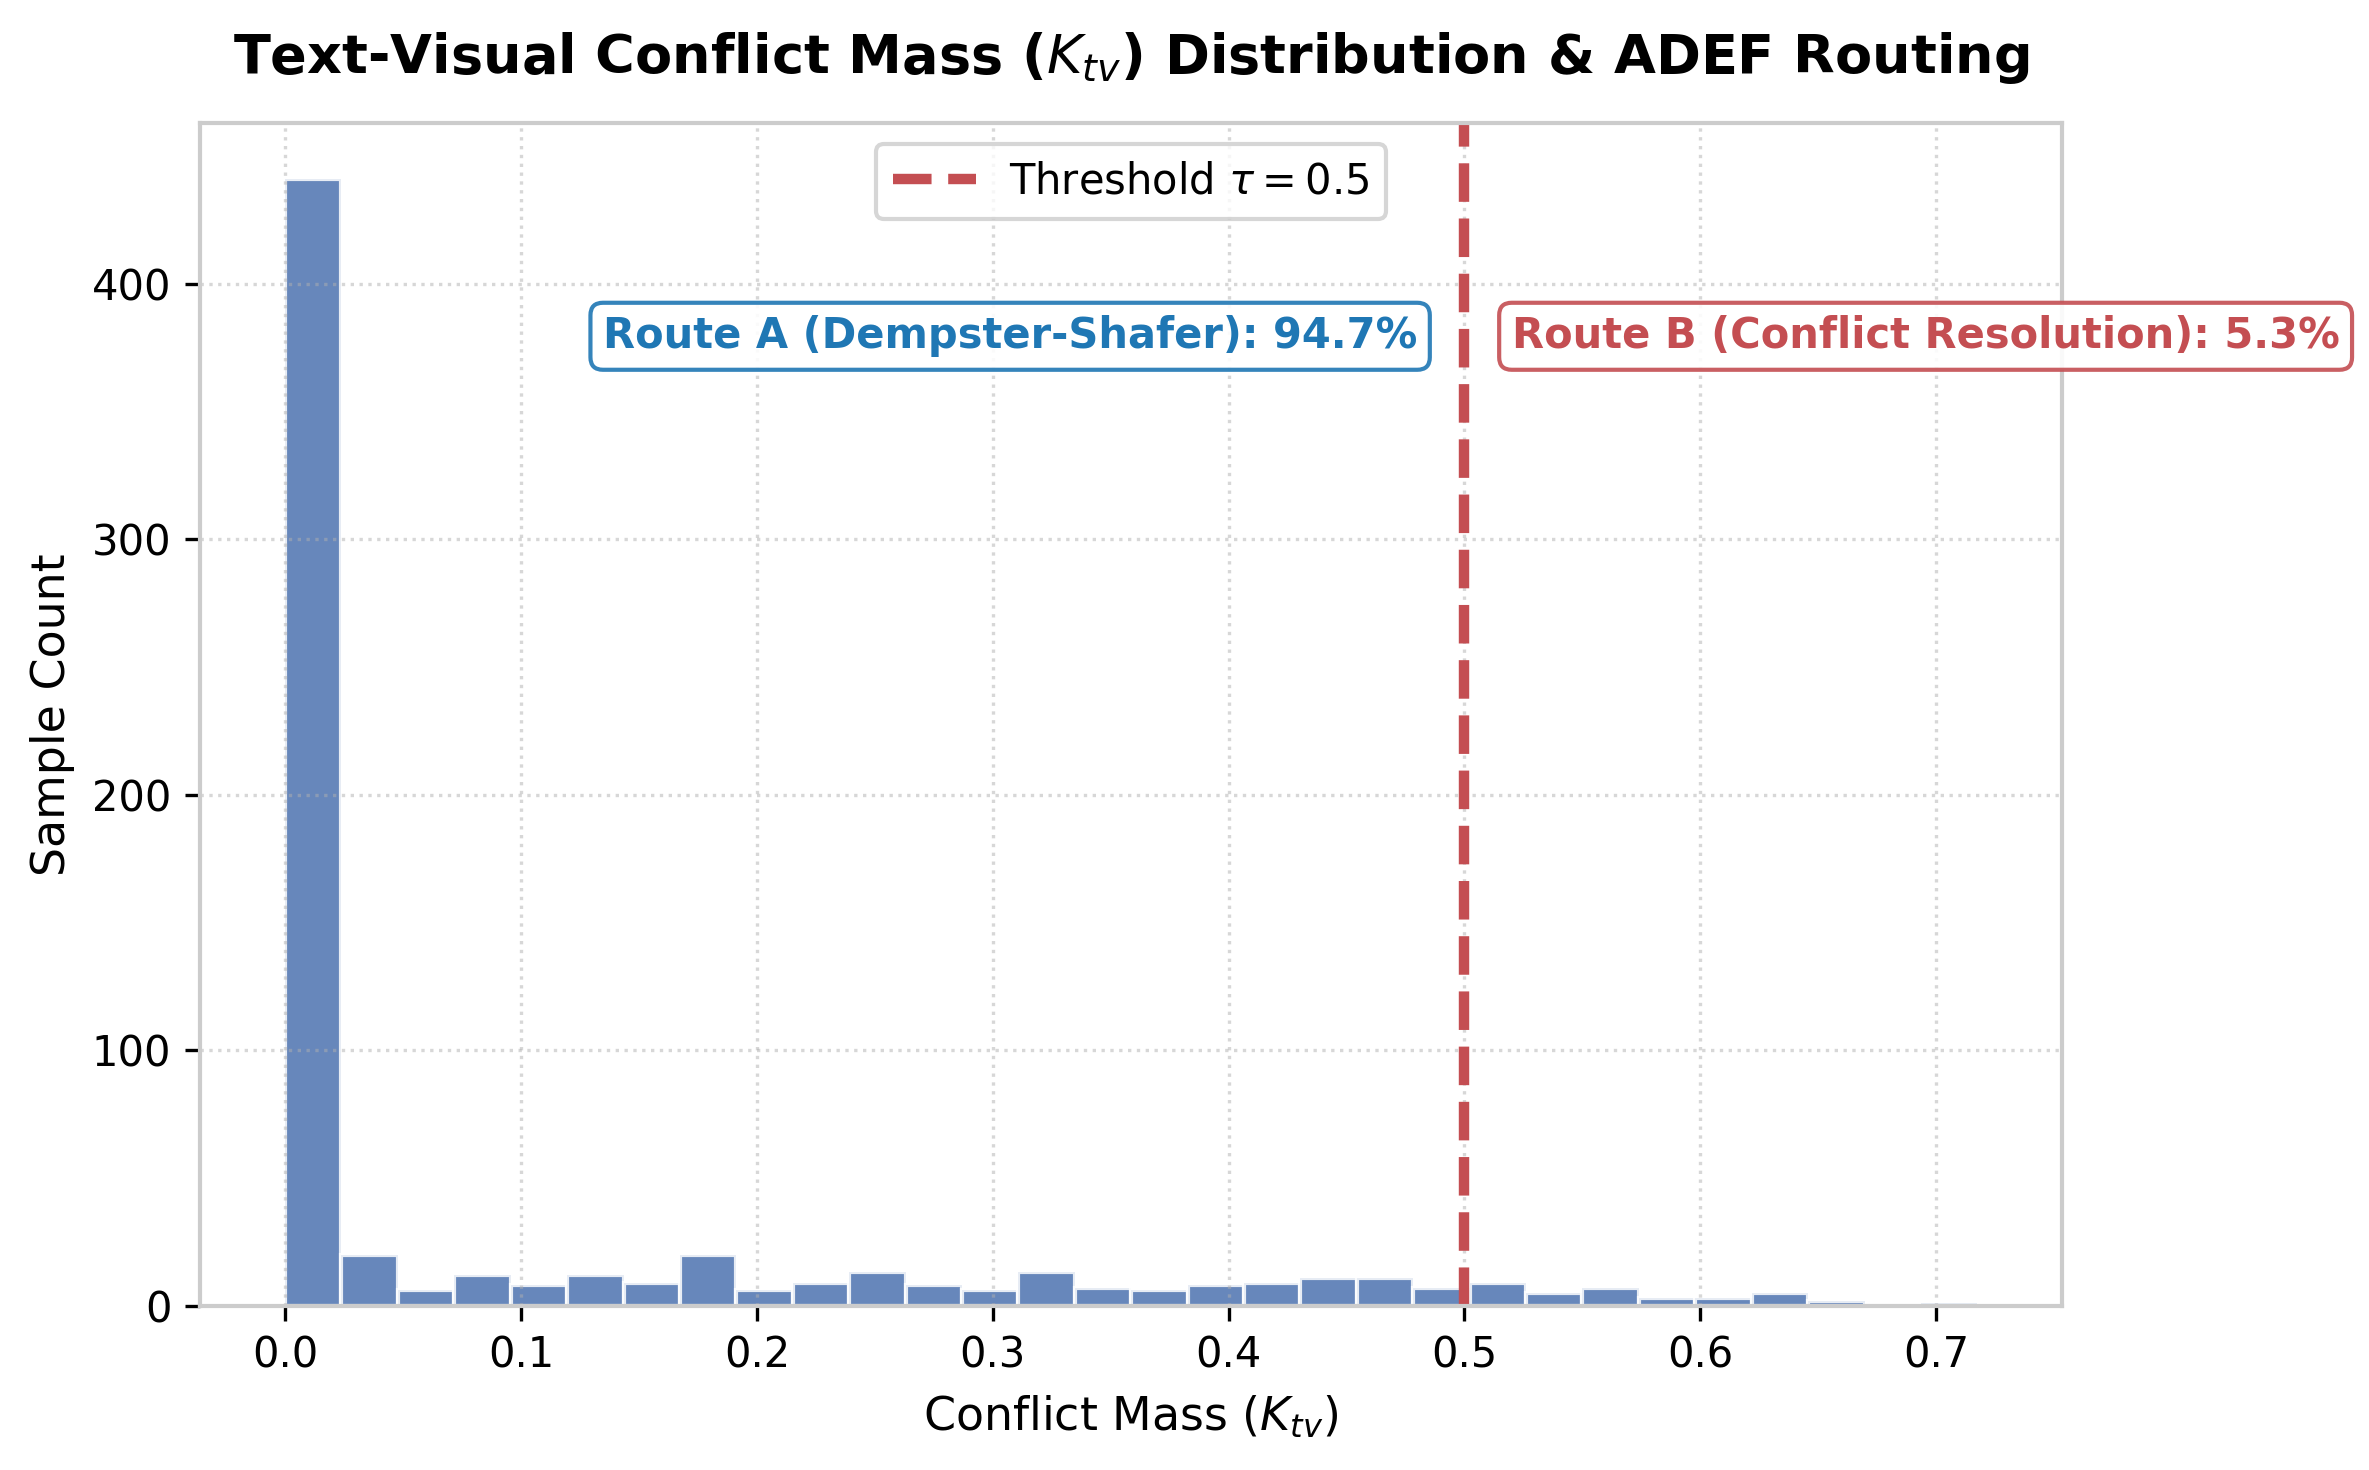

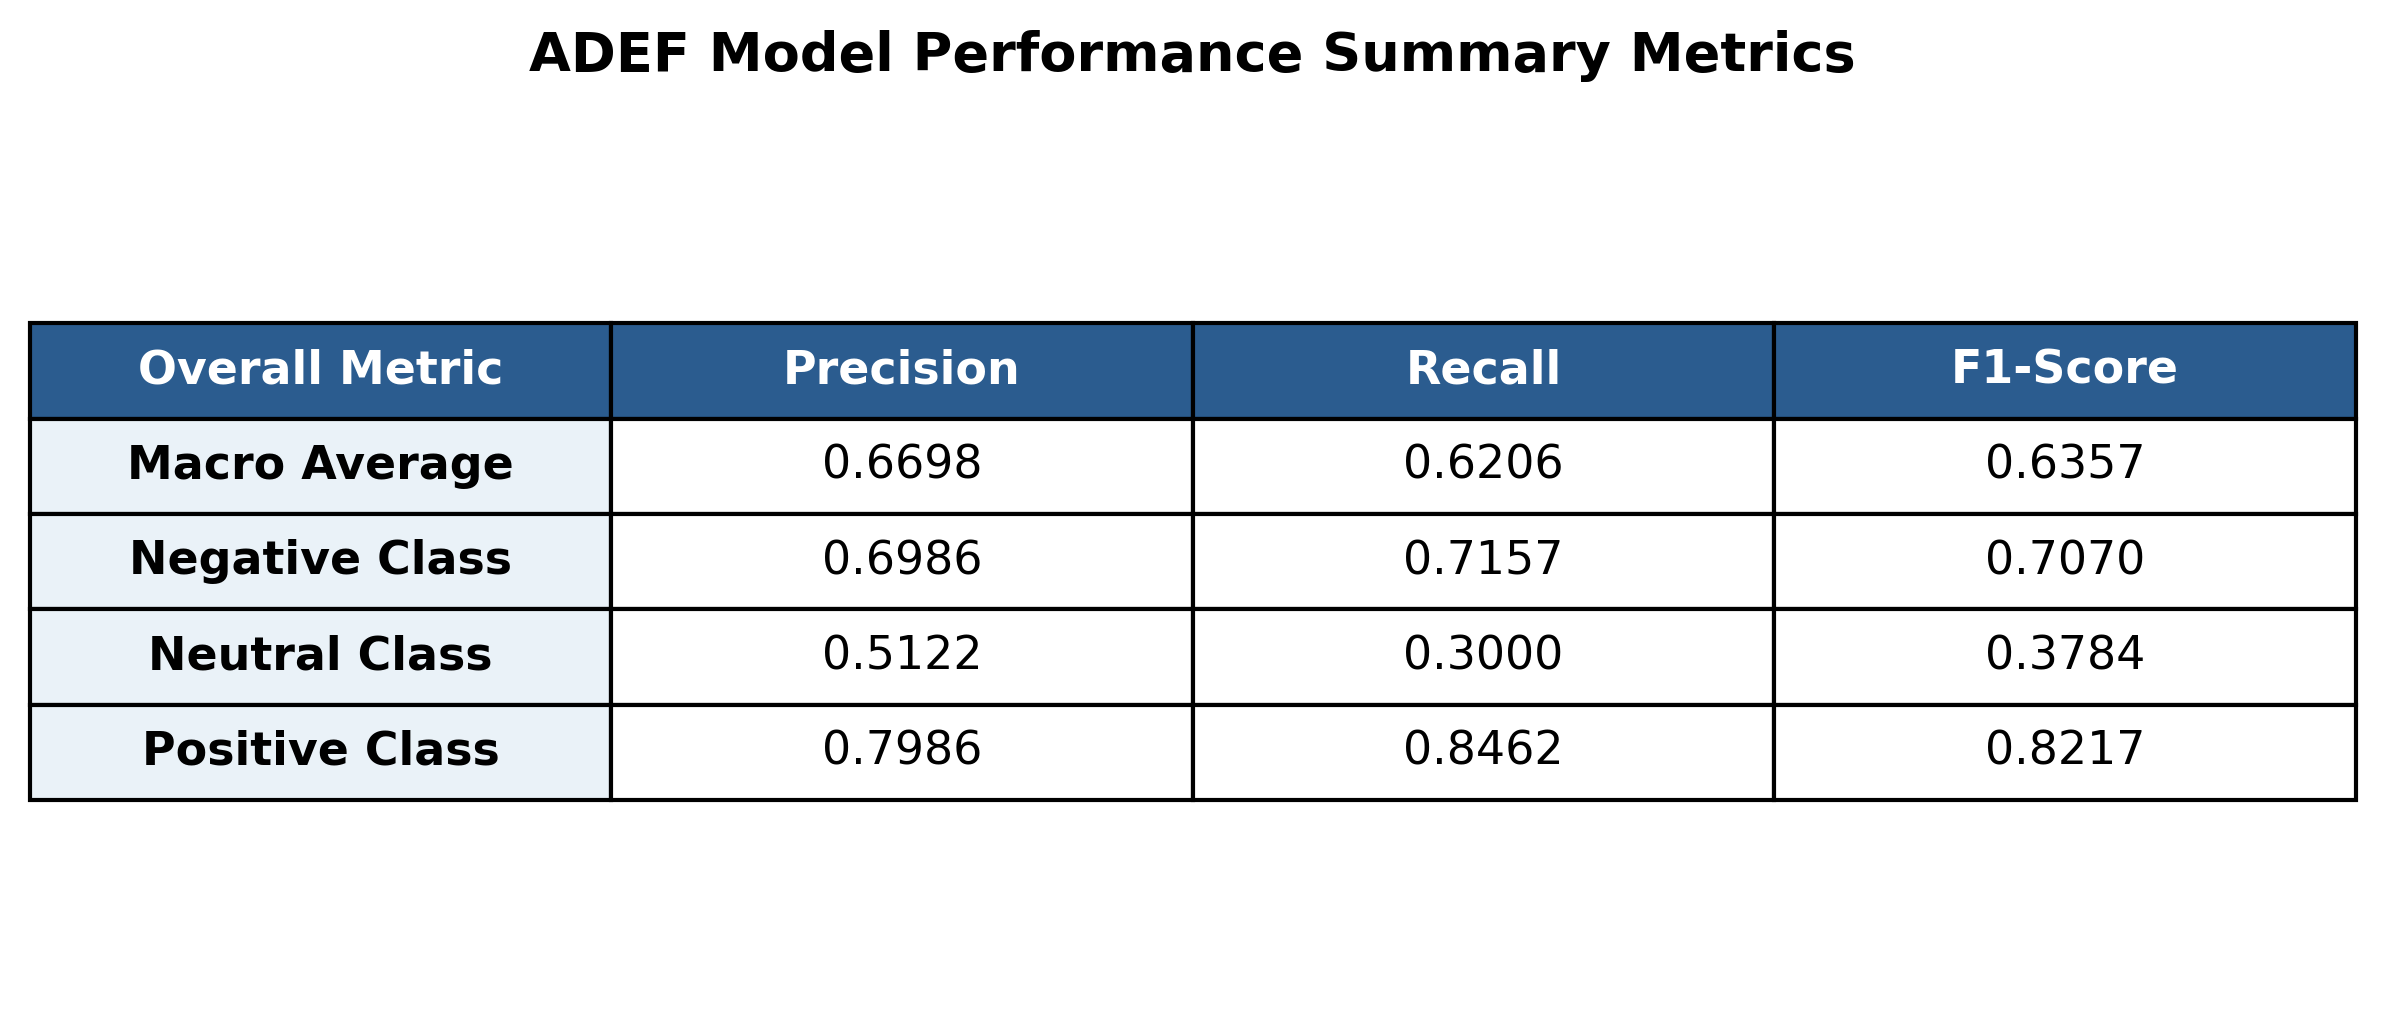

[INFO] All 5 publication-grade visualization plots rendered & saved.


In [9]:
# ============================================================
# PUBLICATION-GRADE VISUALIZATIONS (300 DPI)
# ============================================================

plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 1.0

# ------------------------------------------------------------
# 1. Confusion Matrix Diagram
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = [f"{v}\n({p:.1%})" for v, p in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(3, 3)

sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=True, ax=ax,
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 11, "weight": "bold"})
ax.set_title("ADEF Model Confusion Matrix (Test Set)", fontsize=13, pad=12, weight="bold")
ax.set_xlabel("Predicted Sentiment Label", fontsize=11, labelpad=8)
ax.set_ylabel("True Sentiment Label", fontsize=11, labelpad=8)
plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"confusion_matrix.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

# ------------------------------------------------------------
# 2. Training Dynamics & Performance Curves
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

epochs_range = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_range, history["train_loss"], "o-", color="#1f77b4", label="Train Loss", linewidth=2)
ax1.plot(epochs_range, history["val_loss"], "s--", color="#ff7f0e", label="Val Loss", linewidth=2)
ax1.set_title("EDL Training & Validation Loss", fontsize=12, weight="bold")
ax1.set_xlabel("Epoch", fontsize=10)
ax1.set_ylabel("Loss", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(frameon=True)

ax2.plot(epochs_range, history["train_acc"], "o-", color="#2ca02c", label="Train Acc", linewidth=2)
ax2.plot(epochs_range, history["val_acc"], "s--", color="#d62728", label="Val Acc", linewidth=2)
ax2.plot(epochs_range, history["val_f1"], "^-.", color="#9467bd", label="Val Macro F1", linewidth=2)
ax2.set_title("Accuracy & Macro F1 Curves", fontsize=12, weight="bold")
ax2.set_xlabel("Epoch", fontsize=10)
ax2.set_ylabel("Score", fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(frameon=True)

plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"training_dynamics.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

# ------------------------------------------------------------
# 3. Uncertainty Mass (u_fusion) Distribution Plot
# ------------------------------------------------------------
correct_mask = (test_preds == test_labels)
u_correct = test_u_fusion[correct_mask]
u_incorrect = test_u_fusion[~correct_mask]

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
sns.kdeplot(u_correct, label=f"Correct Predictions (N={len(u_correct)})", fill=True, color="#2ca02c", alpha=0.4, linewidth=2, ax=ax)
sns.kdeplot(u_incorrect, label=f"Incorrect Predictions (N={len(u_incorrect)})", fill=True, color="#d62728", alpha=0.4, linewidth=2, ax=ax)
ax.set_title("Uncertainty Mass ($u_{fusion}$) Density Distribution", fontsize=13, pad=12, weight="bold")
ax.set_xlabel("Fused Uncertainty Mass ($u_{fusion}$)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(frameon=True)
plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"uncertainty_distribution.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

# ------------------------------------------------------------
# 4. Conflict Mass (K_tv) Analysis & Routing Distribution
# ------------------------------------------------------------
route_a_pct = (test_K_tv <= CFG.TAU_THRESHOLD).mean() * 100
route_b_pct = (test_K_tv > CFG.TAU_THRESHOLD).mean() * 100

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
n, bins, patches = ax.hist(test_K_tv, bins=30, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.axvline(CFG.TAU_THRESHOLD, color="#c44e52", linestyle="--", linewidth=2.5,
           label=f"Threshold $\\tau = {CFG.TAU_THRESHOLD}$")

ax.text(CFG.TAU_THRESHOLD - 0.02, max(n)*0.85, f"Route A (Dempster-Shafer): {route_a_pct:.1f}%",
        horizontalalignment="right", fontsize=10, weight="bold", color="#1f77b4",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#1f77b4", alpha=0.9))

ax.text(CFG.TAU_THRESHOLD + 0.02, max(n)*0.85, f"Route B (Conflict Resolution): {route_b_pct:.1f}%",
        horizontalalignment="left", fontsize=10, weight="bold", color="#c44e52",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#c44e52", alpha=0.9))

ax.set_title("Text-Visual Conflict Mass ($K_{tv}$) Distribution & ADEF Routing", fontsize=13, pad=12, weight="bold")
ax.set_xlabel("Conflict Mass ($K_{tv}$)", fontsize=11)
ax.set_ylabel("Sample Count", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(frameon=True, loc="upper center")
plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"conflict_routing_distribution.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

# ------------------------------------------------------------
# 5. Comprehensive Metrics Summary Table Plot
# ------------------------------------------------------------
precisions = precision_score(test_labels, test_preds, average=None)
recalls = recall_score(test_labels, test_preds, average=None)
f1s = f1_score(test_labels, test_preds, average=None)

table_data = [
    ["Overall Metric", "Precision", "Recall", "F1-Score"],
    ["Macro Average", f"{test_precision_macro:.4f}", f"{test_recall_macro:.4f}", f"{test_f1_macro:.4f}"],
    ["Negative Class", f"{precisions[0]:.4f}", f"{recalls[0]:.4f}", f"{f1s[0]:.4f}"],
    ["Neutral Class", f"{precisions[1]:.4f}", f"{recalls[1]:.4f}", f"{f1s[1]:.4f}"],
    ["Positive Class", f"{precisions[2]:.4f}", f"{recalls[2]:.4f}", f"{f1s[2]:.4f}"]
]

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=300)
ax.axis("off")
table = ax.table(cellText=table_data, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Style Header & Column Headers
for i in range(4):
    cell = table[(0, i)]
    cell.set_facecolor("#2b5c8f")
    cell.get_text().set_color("white")
    cell.get_text().set_weight("bold")

for j in range(1, 5):
    cell = table[(j, 0)]
    cell.set_facecolor("#eaf2f8")
    cell.get_text().set_weight("bold")

ax.set_title("ADEF Model Performance Summary Metrics", fontsize=13, pad=15, weight="bold")
plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"metrics_summary_table.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

print("[INFO] All 5 publication-grade visualization plots rendered & saved.")
